# HLA-B*2709 complexed with the vasoactive intestinal peptide type 1 receptor (VIPR) peptide
https://www.rcsb.org/structure/1of2

## Build topology files

### Keep only protein system (remove `HETATM`)

#### VIPR$^{+}$

```sh
grep -E 'ATOM\s+[0-9]+\s+[A-Z]+\s+[A-Z]+\s+A' 1of2.pdb > 1of2_hlaB_VIPR.pdb
echo "TER" >> 1of2_hlaB_VIPR.pdb
grep -E 'ATOM\s+[0-9]+\s+[A-Z]+\s+[A-Z]+\s+B' 1of2.pdb >> 1of2_hlaB_VIPR.pdb
echo "TER" >> 1of2_hlaB_VIPR.pdb
grep -E 'ATOM\s+[0-9]+\s+[A-Z]+\s+[A-Z]+\s+C' 1of2.pdb >> 1of2_hlaB_VIPR.pdb
echo "TER" >> 1of2_hlaB_VIPR.pdb
```

#### VIPR$^{-}$

Delete chain C (VIPR) manually from a copy of the resultant file above

### Disulfide bonds & heavy atoms
`pdb4amber`: MUST be run in `ppis` conda environment

In [2]:
!grep 'SSBOND' ~/project/a02int/hla-b2709_vipr_1of2/1of2.pdb

SSBOND   1 CYS A  101    CYS A  164                          1555   1555  2.05  
SSBOND   2 CYS A  203    CYS A  259                          1555   1555  2.03  
SSBOND   3 CYS B   25    CYS B   80                          1555   1555  2.05  


#### VIPR$^{+}$

In [5]:
!pdb4amber -i ~/project/a02int/hla-b2709_vipr_1of2/1of2_hlaB_VIPR.pdb -o ~/project/a02int/hla-b2709_vipr_1of2/1of2_hlaB_VIPR_pdb4amber.pdb


Summary of pdb4amber for: /home/wjoon21/project/a02int/hla-b2709_vipr_1of2/1of2_hlaB_VIPR.pdb

----------Chains
The following (original) chains have been found:
A
B
C

---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
GLN_72
GLU_166
ARG_169
ASP_196
ARG_3
HIS_31
-----------Non-standard-resnames


---------- Missing heavy atom(s)

HIS_3 misses 4 heavy atom(s)
ARG_6 misses 2 heavy atom(s)
TYR_7 misses 4 heavy atom(s)
PHE_8 misses 4 heavy atom(s)
HIS_9 misses 4 heavy atom(s)
THR_10 misses 2 heavy atom(s)
VAL_12 misses 2 heavy atom(s)
ARG_14 misses 2 heavy atom(s)
ARG_17 misses 2 heavy atom(s)
GLU_19 misses 2 heavy atom(s)
ARG_21 misses 2 heavy atom(s)
PHE_22 misses 4 heavy atom(s)
ILE_23 misses 3 heavy atom(s)
THR_24 misses 2 heavy atom(s)
VAL_25 misses 2 heavy atom(s)
TYR_27 misses 4 heavy atom(s)
VAL_28 misses 2 heavy atom(s)
ASP_29 misses 2 heavy atom(s)
ASP_30 misses 2 heavy atom(s)
THR_31 misses 2 heavy atom(s)
LEU_32 misses 2 heavy

#### VIPR$^{-}$

In [6]:
!pdb4amber -i ~/project/a02int/hla-b2709_vipr_1of2/1of2_hlaB_noVIPR.pdb -o ~/project/a02int/hla-b2709_vipr_1of2/1of2_hlaB_noVIPR_pdb4amber.pdb


Summary of pdb4amber for: /home/wjoon21/project/a02int/hla-b2709_vipr_1of2/1of2_hlaB_noVIPR.pdb

----------Chains
The following (original) chains have been found:
A
B

---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
GLN_72
GLU_166
ARG_169
ASP_196
ARG_3
HIS_31
-----------Non-standard-resnames


---------- Missing heavy atom(s)

HIS_3 misses 4 heavy atom(s)
ARG_6 misses 2 heavy atom(s)
TYR_7 misses 4 heavy atom(s)
PHE_8 misses 4 heavy atom(s)
HIS_9 misses 4 heavy atom(s)
THR_10 misses 2 heavy atom(s)
VAL_12 misses 2 heavy atom(s)
ARG_14 misses 2 heavy atom(s)
ARG_17 misses 2 heavy atom(s)
GLU_19 misses 2 heavy atom(s)
ARG_21 misses 2 heavy atom(s)
PHE_22 misses 4 heavy atom(s)
ILE_23 misses 3 heavy atom(s)
THR_24 misses 2 heavy atom(s)
VAL_25 misses 2 heavy atom(s)
TYR_27 misses 4 heavy atom(s)
VAL_28 misses 2 heavy atom(s)
ASP_29 misses 2 heavy atom(s)
ASP_30 misses 2 heavy atom(s)
THR_31 misses 2 heavy atom(s)
LEU_32 misses 2 heavy

i.e., seems like there were missing atoms in the original PDB?

### Solvate system in cubic box
`tleap`\
Refer to `12_noLigand.ipynb` (FSC$^{-}$ case $\because$ only protein & peptide in current system) for commands

#### VIPR$^{+}$

In [7]:
volumeBoxAngstrom = 851072.593
volumeBoxLiter = volumeBoxAngstrom * 1/(10**10)**3 * (10**2)**3/1 * 1/1 * 1/10**3
numberClLiter = 150/1 * 1/10**3 * (6.022*10**23)/1
numberClBox = volumeBoxLiter * numberClLiter
numberClBox

76.87738732568998

Output:
```
1of2_hlaB_VIPR_pdb4amber_tleap_cubic_ion.parm7
1of2_hlaB_VIPR_pdb4amber_tleap_cubic_ion.rst7
```

#### VIPR$^{-}$

##### (NG) directly input `.pdb` into `tleap` before `pdb4amber` changes CYS in disulfide bonds to CYX

In [8]:
volumeBoxAngstrom = 868494.655
volumeBoxLiter = volumeBoxAngstrom * 1/(10**10)**3 * (10**2)**3/1 * 1/1 * 1/10**3
numberClLiter = 150/1 * 1/10**3 * (6.022*10**23)/1
numberClBox = volumeBoxLiter * numberClLiter
numberClBox

78.45112218615

##### (FIXED) output: `1of2_hlaB_noVIPR_pdb4amber_tleap_cubic_ion`

seems like changing CYS to CYX has no affect to the solvent box volume

## Minimize, heat, equilibrate system + 50 ns NPT production MD
(NG?) VIPR$^{-}$ was restrained the same as VIPR$^{+}$ (residues 1-385)\
VIPR residues should have been removed (residues 377-385)

NPT production NG comparison to NVT US/HREMD...?

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mdtraj as md
import pytraj as pt

In [76]:
parm_VIPR_dry_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/min_equil_prod/finished/1of2_hlaB_VIPR_pdb4amber_tleap_dry.parm7'
mdcrd_VIPR_dry_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/min_equil_prod/finished/prod_md_dry.nc'

traj_VIPR_dry = pt.load(mdcrd_VIPR_dry_path, top=parm_VIPR_dry_path)
print(traj_VIPR_dry)

pytraj.Trajectory, 2500 frames: 
Size: 0.347067 (GB)
<Topology: 6211 atoms, 385 residues, 3 mols, PBC with box type = orthorhombic>
           


In [75]:
parm_noVIPR_dry_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/min_equil_prod/finished/1of2_hlaB_noVIPR_pdb4amber_tleap_cpptraj_dry.parm7'
mdcrd_noVIPR_dry_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/min_equil_prod/finished/prod_md_dry.nc'

traj_noVIPR_dry = pt.load(mdcrd_noVIPR_dry_path, top=parm_noVIPR_dry_path)
print(traj_noVIPR_dry)

pytraj.Trajectory, 2500 frames: 
Size: 0.335611 (GB)
<Topology: 6006 atoms, 376 residues, 2 mols, PBC with box type = orthorhombic>
           


In [77]:
# List of atom indices
Rint_atom_indicesList = [113, 115, 118, 119, 121, 158, 355, 362, 388, 415, 
                         417, 418, 548, 550, 554, 1489, 1516, 1519, 1522, 1523, 
                         1524, 1807, 1809, 1835, 1864, 1866, 1869, 1871, 1876, 3032, 
                         3634, 3636, 3640, 3656, 3657, 3658, 3677, 3679, 3682, 3685, 
                         3688, 3690, 3691, 3694, 3700, 3703, 3706, 3715, 3725, 3739, 
                         3811, 3812, 3849, 3854]

# Create the mask string
Rint_atom_indicesStr = ",".join(f"@{i}" for i in Rint_atom_indicesList)
print(Rint_atom_indicesStr)

@113,@115,@118,@119,@121,@158,@355,@362,@388,@415,@417,@418,@548,@550,@554,@1489,@1516,@1519,@1522,@1523,@1524,@1807,@1809,@1835,@1864,@1866,@1869,@1871,@1876,@3032,@3634,@3636,@3640,@3656,@3657,@3658,@3677,@3679,@3682,@3685,@3688,@3690,@3691,@3694,@3700,@3703,@3706,@3715,@3725,@3739,@3811,@3812,@3849,@3854


In [78]:
rmsd_Rint_VIPR_array = pt.rmsd(traj_VIPR_dry, ref=0, mask=f"{Rint_atom_indicesStr}&!@H*")
print(rmsd_Rint_VIPR_array, len(rmsd_Rint_VIPR_array), sep='\n')

[3.17891439e-07 6.90159390e-01 7.67177543e-01 ... 2.50942930e+00
 2.56999611e+00 2.61029591e+00]
2500


In [80]:
rmsd_time_Rint_VIPR_df = pd.DataFrame({'Time (ps)': traj_VIPR_dry.time, 'RMSD (Å)': rmsd_Rint_VIPR_array})
display(rmsd_time_Rint_VIPR_df)

,Time (ps),RMSD (Å)
0,4020.0,3.178914e-07
1,4040.0,6.901594e-01
2,4060.0,7.671775e-01
3,4080.0,7.374192e-01
4,4100.0,8.607198e-01
...,...,...
2495,53920.0,2.422300e+00
2496,53940.0,2.439969e+00
2497,53960.0,2.509429e+00
2498,53980.0,2.569996e+00


In [79]:
rmsd_Rint_noVIPR_array = pt.rmsd(traj_noVIPR_dry, ref=0, mask=f"{Rint_atom_indicesStr}&!@H*")
print(rmsd_Rint_noVIPR_array, len(rmsd_Rint_noVIPR_array), sep='\n')

[3.89335909e-07 7.22419000e-01 7.19200405e-01 ... 1.87009139e+00
 1.88047091e+00 1.89426927e+00]
2500


In [81]:
rmsd_time_Rint_noVIPR_df = pd.DataFrame({'Time (ps)': traj_noVIPR_dry.time, 'RMSD (Å)': rmsd_Rint_noVIPR_array})
display(rmsd_time_Rint_noVIPR_df)

,Time (ps),RMSD (Å)
0,4020.0,3.893359e-07
1,4040.0,7.224190e-01
2,4060.0,7.192004e-01
3,4080.0,6.449125e-01
4,4100.0,8.000055e-01
...,...,...
2495,53920.0,2.017059e+00
2496,53940.0,1.875295e+00
2497,53960.0,1.870091e+00
2498,53980.0,1.880471e+00


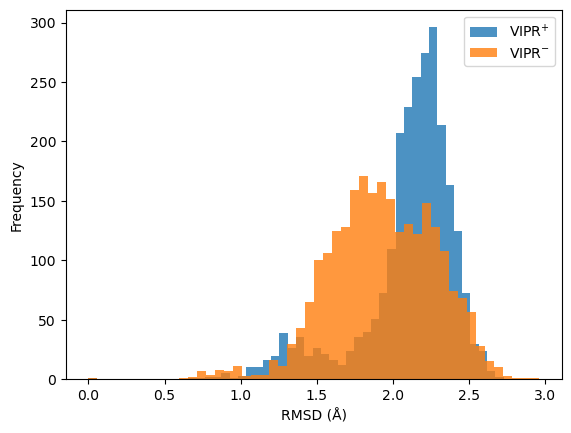

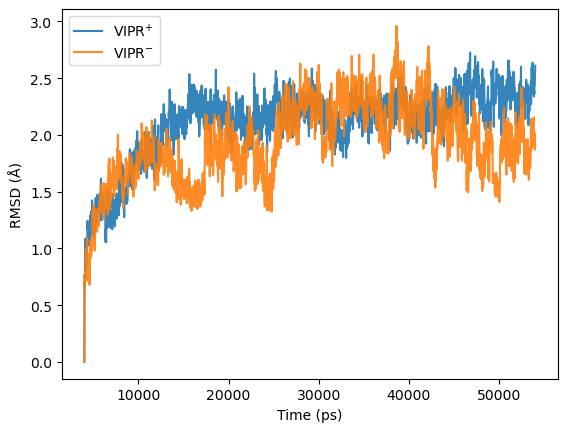

In [82]:
sns.histplot(rmsd_time_Rint_VIPR_df['RMSD (Å)'], bins=50, label='VIPR$^{+}$', alpha=0.8, edgecolor='none')
sns.histplot(rmsd_time_Rint_noVIPR_df['RMSD (Å)'], bins=50, label='VIPR$^{-}$', alpha=0.8, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(loc='best')

plt.show()

sns.lineplot(data=rmsd_time_Rint_VIPR_df, x="Time (ps)", y="RMSD (Å)", label='VIPR$^{+}$', alpha=0.9)
sns.lineplot(data=rmsd_time_Rint_noVIPR_df, x="Time (ps)", y="RMSD (Å)", label='VIPR$^{-}$', alpha=0.9)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(loc='best')

plt.show()

## Obtain interface atoms and coordinates

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
def process_pdb_as_txt_dist_tuple_dict(file, va1, va2, va3, va4, dd=16.0):
    a, xa, b, xb = [], [], [], []
    distance_dict = {}  # Initialize the dictionary to store distances

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM" and not fields[2].startswith("H") and fields[2] not in ["C", "N", "O"]:
                if va1 <= int(fields[4]) <= va2:
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])
                elif va3 <= int(fields[4]) <= va4:
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            if d < dd:
                ima[n] = True
                imb[j] = True
                # Add the distance to the dictionary, using the atom serial number as the key
                if a[n] in distance_dict:
                    distance_dict[a[n]].append((b[j], d))  # Store the atom and distance as a tuple
                else:
                    distance_dict[a[n]] = [(b[j], d)]  # Store the atom and distance as a tuple

    max_count = np.sum(ima) + np.sum(imb)
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers (2), total count, coordinates (2), and the distance dictionary
    return output_a, output_b, max_count, output_xa, output_xb, distance_dict

In [10]:
def get_coordinates_list(file, atom_indices):
    coordinates = [] 

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM" and int(fields[1]) in atom_indices:
                # Append the coordinates directly to the list
                coordinates.extend(float(fields[i]) for i in range(5, 8))

    return coordinates

### Get interface atoms from solvated PDB (before AMBER)
VIPR$^{+}$ = VIPR$^{-}$

In [26]:
path2_1of2_VIPR_pdb = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/1of2_hlaB_VIPR_pdb4amber_tleap_cubic_ion.pdb'

In [27]:
(int_atom_c1_nonHCNO_1of2, int_atom_c2_nonHCNO_1of2, 
 num_int_atom_nonHCNO_1of2, 
 xyz_c1_nonHCNO_1of2, xyz_c2_nonHCNO_1of2, 
 sqdist_tuple_dict_nonHCNO_1of2) = process_pdb_as_txt_dist_tuple_dict(path2_1of2_VIPR_pdb, 1, 276, 277, 376, dd=16.0)

#### Receptor

In [28]:
print(int_atom_c1_nonHCNO_1of2)

[ 113  115  118  119  121  158  355  362  388  415  417  418  548  550
  554 1489 1516 1519 1522 1523 1524 1807 1809 1835 1864 1866 1869 1871
 1876 3032 3634 3636 3640 3656 3657 3658 3677 3679 3682 3685 3688 3690
 3691 3694 3700 3703 3706 3715 3725 3739 3811 3812 3849 3854]


In [29]:
int_atom_index_c1_nonHCNO_1of2_list = int_atom_c1_nonHCNO_1of2.tolist()
print(int_atom_index_c1_nonHCNO_1of2_list)

[113, 115, 118, 119, 121, 158, 355, 362, 388, 415, 417, 418, 548, 550, 554, 1489, 1516, 1519, 1522, 1523, 1524, 1807, 1809, 1835, 1864, 1866, 1869, 1871, 1876, 3032, 3634, 3636, 3640, 3656, 3657, 3658, 3677, 3679, 3682, 3685, 3688, 3690, 3691, 3694, 3700, 3703, 3706, 3715, 3725, 3739, 3811, 3812, 3849, 3854]


In [30]:
len(int_atom_index_c1_nonHCNO_1of2_list)

54

#### Ligand

In [34]:
print(int_atom_c2_nonHCNO_1of2)

[4379 4380 4441 4490 4522 4525 4526 4527 4552 4555 4556 4558 4560 4561
 4582 4587 4590 4593 4599 4776 4798 4799 4801 4803 4804 4832 4835 4874
 4875 4877 5219 5221 5224 5225 5226 5231 5233 5242 5252 5255 5267 5269
 5271 5273 5275 5326 5328 5331 5332 5334 5339 5369 5371 5373 5375 5392
 5432 5981 5991 6006]


In [37]:
int_atom_index_c2_nonHCNO_1of2_list = int_atom_c2_nonHCNO_1of2.tolist()
print(int_atom_index_c2_nonHCNO_1of2_list)

[4379, 4380, 4441, 4490, 4522, 4525, 4526, 4527, 4552, 4555, 4556, 4558, 4560, 4561, 4582, 4587, 4590, 4593, 4599, 4776, 4798, 4799, 4801, 4803, 4804, 4832, 4835, 4874, 4875, 4877, 5219, 5221, 5224, 5225, 5226, 5231, 5233, 5242, 5252, 5255, 5267, 5269, 5271, 5273, 5275, 5326, 5328, 5331, 5332, 5334, 5339, 5369, 5371, 5373, 5375, 5392, 5432, 5981, 5991, 6006]


In [38]:
len(int_atom_index_c2_nonHCNO_1of2_list)

60

#### Receptor + ligand

In [41]:
int_atom_index_nonHCNO_1of2_list = int_atom_index_c1_nonHCNO_1of2_list + int_atom_index_c2_nonHCNO_1of2_list
print(int_atom_index_nonHCNO_1of2_list)

[113, 115, 118, 119, 121, 158, 355, 362, 388, 415, 417, 418, 548, 550, 554, 1489, 1516, 1519, 1522, 1523, 1524, 1807, 1809, 1835, 1864, 1866, 1869, 1871, 1876, 3032, 3634, 3636, 3640, 3656, 3657, 3658, 3677, 3679, 3682, 3685, 3688, 3690, 3691, 3694, 3700, 3703, 3706, 3715, 3725, 3739, 3811, 3812, 3849, 3854, 4379, 4380, 4441, 4490, 4522, 4525, 4526, 4527, 4552, 4555, 4556, 4558, 4560, 4561, 4582, 4587, 4590, 4593, 4599, 4776, 4798, 4799, 4801, 4803, 4804, 4832, 4835, 4874, 4875, 4877, 5219, 5221, 5224, 5225, 5226, 5231, 5233, 5242, 5252, 5255, 5267, 5269, 5271, 5273, 5275, 5326, 5328, 5331, 5332, 5334, 5339, 5369, 5371, 5373, 5375, 5392, 5432, 5981, 5991, 6006]


In [44]:
len(int_atom_index_nonHCNO_1of2_list)

114

### Get interface atom coordinates from equilibrated PDB
VIPR$^{+}$ $\neq$ VIPR$^{-}$

#### VIPR$^{+}$

In [31]:
path2_1of2_VIPR_9md_dry_pdb = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/min_equil_prod/finished/1of2_hlaB_VIPR_pdb4amber_tleap_9md_dry.pdb'

##### Receptor

In [36]:
int_crds_c1_1of2_VIPR_9md_dry = get_coordinates_list(path2_1of2_VIPR_9md_dry_pdb, int_atom_index_c1_nonHCNO_1of2_list)
print(int_crds_c1_1of2_VIPR_9md_dry)

[37.997, 40.293, 34.299, 38.772, 40.626, 35.582, 39.276, 39.36, 36.305, 40.575, 38.924, 35.963, 41.087, 37.763, 36.582, 34.647, 46.188, 37.147, 36.036, 49.063, 36.906, 38.989, 49.83, 36.801, 41.478, 43.291, 36.527, 45.304, 38.329, 38.636, 44.501, 39.493, 38.687, 44.209, 40.078, 39.873, 43.332, 50.959, 34.138, 43.012, 52.247, 34.492, 42.524, 52.438, 35.691, 27.9, 43.856, 42.602, 30.896, 39.892, 38.533, 31.0, 40.753, 39.846, 29.803, 40.837, 40.753, 29.224, 39.854, 41.171, 29.478, 42.048, 41.156, 32.48, 30.319, 35.869, 32.31, 30.32, 37.23, 28.43, 36.539, 39.586, 26.032, 41.215, 43.56, 24.83, 41.845, 44.286, 24.801, 43.388, 44.482, 25.717, 44.06, 43.944, 28.876, 38.781, 44.439, 60.913, 37.723, 64.713, 50.058, 35.923, 57.207, 51.229, 35.732, 56.3, 49.671, 37.346, 57.068, 43.846, 35.354, 52.505, 43.844, 34.404, 53.344, 42.878, 35.503, 51.763, 49.849, 39.1, 49.599, 49.875, 39.978, 50.892, 51.159, 39.857, 51.666, 51.207, 40.206, 53.173, 52.57, 40.433, 53.743, 52.843, 40.546, 55.085, 51.894, 40

In [33]:
len(int_crds_1of2_VIPR_9md_dry)

162

##### Ligand

In [39]:
int_crds_c2_1of2_VIPR_9md_dry = get_coordinates_list(path2_1of2_VIPR_9md_dry_pdb, int_atom_index_c2_nonHCNO_1of2_list)
print(int_crds_c2_1of2_VIPR_9md_dry)

[24.1, 43.655, 49.629, 25.396, 44.008, 48.468, 29.736, 37.895, 47.736, 37.773, 39.235, 58.522, 47.459, 41.551, 55.281, 48.148, 40.242, 54.9, 49.076, 39.867, 55.592, 47.655, 39.401, 54.067, 53.821, 44.0, 54.631, 53.053, 43.739, 53.306, 53.792, 43.471, 52.073, 53.126, 43.272, 50.869, 51.715, 43.332, 50.935, 51.068, 43.248, 49.84, 58.687, 45.1, 49.549, 59.337, 45.165, 47.115, 59.622, 45.947, 45.77, 58.363, 46.59, 45.302, 57.2, 47.899, 43.964, 54.557, 46.197, 49.549, 47.004, 43.279, 49.602, 46.337, 42.165, 50.135, 45.543, 41.386, 49.226, 45.504, 41.618, 47.838, 44.659, 40.974, 47.03, 41.87, 40.839, 50.225, 42.279, 40.355, 51.532, 28.902, 42.857, 47.31, 28.175, 42.834, 46.145, 29.001, 42.371, 45.188, 42.793, 47.722, 39.022, 42.698, 47.52, 37.447, 43.229, 48.805, 36.716, 44.296, 48.812, 36.12, 42.649, 49.891, 36.779, 39.813, 45.805, 40.482, 38.385, 46.45, 40.512, 36.048, 46.123, 41.509, 41.258, 41.399, 40.031, 41.041, 40.118, 39.473, 35.704, 37.829, 40.353, 35.095, 37.663, 39.074, 34.889, 38

In [40]:
len(int_crds_c2_1of2_VIPR_9md_dry)

180

##### Receptor + ligand

In [42]:
int_crds_1of2_VIPR_9md_dry = int_crds_c1_1of2_VIPR_9md_dry + int_crds_c2_1of2_VIPR_9md_dry
print(int_crds_1of2_VIPR_9md_dry)

[37.997, 40.293, 34.299, 38.772, 40.626, 35.582, 39.276, 39.36, 36.305, 40.575, 38.924, 35.963, 41.087, 37.763, 36.582, 34.647, 46.188, 37.147, 36.036, 49.063, 36.906, 38.989, 49.83, 36.801, 41.478, 43.291, 36.527, 45.304, 38.329, 38.636, 44.501, 39.493, 38.687, 44.209, 40.078, 39.873, 43.332, 50.959, 34.138, 43.012, 52.247, 34.492, 42.524, 52.438, 35.691, 27.9, 43.856, 42.602, 30.896, 39.892, 38.533, 31.0, 40.753, 39.846, 29.803, 40.837, 40.753, 29.224, 39.854, 41.171, 29.478, 42.048, 41.156, 32.48, 30.319, 35.869, 32.31, 30.32, 37.23, 28.43, 36.539, 39.586, 26.032, 41.215, 43.56, 24.83, 41.845, 44.286, 24.801, 43.388, 44.482, 25.717, 44.06, 43.944, 28.876, 38.781, 44.439, 60.913, 37.723, 64.713, 50.058, 35.923, 57.207, 51.229, 35.732, 56.3, 49.671, 37.346, 57.068, 43.846, 35.354, 52.505, 43.844, 34.404, 53.344, 42.878, 35.503, 51.763, 49.849, 39.1, 49.599, 49.875, 39.978, 50.892, 51.159, 39.857, 51.666, 51.207, 40.206, 53.173, 52.57, 40.433, 53.743, 52.843, 40.546, 55.085, 51.894, 40

In [43]:
len(int_crds_1of2_VIPR_9md_dry)

342

#### VIPR$^{-}$

In [49]:
path2_1of2_noVIPR_9md_dry_pdb = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/min_equil_prod/finished/1of2_hlaB_noVIPR_pdb4amber_tleap_9md_dry.pdb'

##### Receptor

In [50]:
int_crds_c1_1of2_noVIPR_9md_dry = get_coordinates_list(path2_1of2_noVIPR_9md_dry_pdb, int_atom_index_c1_nonHCNO_1of2_list)
print(int_crds_c1_1of2_noVIPR_9md_dry)

[40.909, 35.383, 34.232, 41.687, 35.664, 35.528, 42.609, 34.539, 35.852, 43.939, 34.533, 35.446, 44.743, 33.419, 35.765, 36.282, 41.109, 36.234, 36.391, 44.21, 35.216, 39.051, 45.807, 35.74, 43.367, 40.059, 35.463, 49.689, 37.092, 37.139, 48.469, 37.802, 37.333, 48.288, 38.609, 38.464, 45.221, 46.448, 31.39, 44.563, 47.273, 30.641, 43.871, 48.039, 31.343, 29.364, 38.436, 40.683, 33.979, 34.959, 37.801, 33.829, 36.197, 38.742, 32.538, 36.204, 39.483, 31.921, 35.158, 39.855, 31.897, 37.407, 39.671, 38.143, 26.933, 36.937, 37.747, 27.683, 37.95, 32.042, 30.926, 39.549, 28.301, 35.658, 42.013, 26.961, 35.827, 42.738, 26.335, 37.146, 42.505, 26.872, 38.003, 41.78, 31.567, 33.942, 42.892, 60.91, 40.859, 63.6, 53.129, 35.756, 55.984, 54.289, 35.665, 55.097, 52.207, 36.95, 55.551, 46.917, 34.251, 51.459, 46.093, 33.517, 52.053, 46.568, 35.309, 50.96, 52.382, 38.016, 47.999, 52.146, 38.899, 49.194, 53.324, 39.273, 50.081, 53.144, 39.994, 51.404, 54.288, 40.737, 51.867, 54.694, 40.964, 53.125, 5

##### Ligand

In [51]:
int_crds_c2_1of2_noVIPR_9md_dry = get_coordinates_list(path2_1of2_noVIPR_9md_dry_pdb, int_atom_index_c2_nonHCNO_1of2_list)
print(int_crds_c2_1of2_noVIPR_9md_dry)

[26.903, 36.036, 48.978, 26.436, 37.442, 47.965, 33.549, 32.81, 46.571, 43.752, 34.517, 52.603, 49.07, 40.502, 53.51, 50.269, 39.548, 53.646, 51.304, 39.92, 54.118, 50.067, 38.324, 53.068, 55.198, 44.725, 51.885, 54.24, 44.207, 50.777, 54.82, 44.075, 49.502, 54.015, 43.529, 48.454, 52.798, 42.906, 48.696, 52.113, 42.342, 47.708, 59.019, 46.358, 46.923, 59.155, 46.207, 44.383, 59.073, 46.999, 43.037, 57.745, 47.539, 42.588, 56.352, 48.797, 41.203, 54.143, 46.262, 47.073, 48.479, 42.299, 47.767, 48.723, 41.234, 48.63, 48.309, 39.938, 48.277, 47.553, 39.691, 47.098, 47.067, 38.422, 46.822, 43.529, 38.649, 48.137, 44.072, 38.043, 49.306, 31.882, 35.887, 48.475, 30.721, 35.203, 48.648, 29.978, 35.245, 47.644, 42.794, 45.161, 37.006, 42.817, 44.966, 35.468, 43.131, 46.334, 34.696, 43.919, 46.414, 33.795, 42.567, 47.353, 35.095, 40.289, 42.7, 38.488, 38.826, 43.17, 38.765, 36.57, 42.586, 39.544, 42.503, 38.672, 38.542, 42.871, 37.373, 38.133, 38.793, 33.617, 39.343, 38.656, 32.979, 38.096, 38

##### Receptor + ligand

In [52]:
int_crds_1of2_noVIPR_9md_dry = int_crds_c1_1of2_noVIPR_9md_dry + int_crds_c2_1of2_noVIPR_9md_dry
print(int_crds_1of2_noVIPR_9md_dry)

[40.909, 35.383, 34.232, 41.687, 35.664, 35.528, 42.609, 34.539, 35.852, 43.939, 34.533, 35.446, 44.743, 33.419, 35.765, 36.282, 41.109, 36.234, 36.391, 44.21, 35.216, 39.051, 45.807, 35.74, 43.367, 40.059, 35.463, 49.689, 37.092, 37.139, 48.469, 37.802, 37.333, 48.288, 38.609, 38.464, 45.221, 46.448, 31.39, 44.563, 47.273, 30.641, 43.871, 48.039, 31.343, 29.364, 38.436, 40.683, 33.979, 34.959, 37.801, 33.829, 36.197, 38.742, 32.538, 36.204, 39.483, 31.921, 35.158, 39.855, 31.897, 37.407, 39.671, 38.143, 26.933, 36.937, 37.747, 27.683, 37.95, 32.042, 30.926, 39.549, 28.301, 35.658, 42.013, 26.961, 35.827, 42.738, 26.335, 37.146, 42.505, 26.872, 38.003, 41.78, 31.567, 33.942, 42.892, 60.91, 40.859, 63.6, 53.129, 35.756, 55.984, 54.289, 35.665, 55.097, 52.207, 36.95, 55.551, 46.917, 34.251, 51.459, 46.093, 33.517, 52.053, 46.568, 35.309, 50.96, 52.382, 38.016, 47.999, 52.146, 38.899, 49.194, 53.324, 39.273, 50.081, 53.144, 39.994, 51.404, 54.288, 40.737, 51.867, 54.694, 40.964, 53.125, 5

## Umbrella sampling

In [45]:
column_names = ["MD time (ps)", "Collective variable (1:1)"]

rmsd_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

labels = [f"Anchor = {rmsd} Å" for rmsd in rmsd_values]

cmap = plt.get_cmap('viridis')

### VIPR$^{+}$

#### Receptor

In [46]:
colv0_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv0.dat'
colv1_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv1.dat'
colv2_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv2.dat'
colv3_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv3.dat'
colv4_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv4.dat'
colv5_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv5.dat'
colv6_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv6.dat'
colv7_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv7.dat'
colv8_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv8.dat'
colv9_VIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/colv9.dat'

colv0_VIPR_Rint_df = pd.read_csv(colv0_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_VIPR_Rint_df)

colv1_VIPR_Rint_df = pd.read_csv(colv1_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_VIPR_Rint_df = pd.read_csv(colv2_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_VIPR_Rint_df = pd.read_csv(colv3_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_VIPR_Rint_df = pd.read_csv(colv4_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_VIPR_Rint_df = pd.read_csv(colv5_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_VIPR_Rint_df = pd.read_csv(colv6_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_VIPR_Rint_df = pd.read_csv(colv7_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_VIPR_Rint_df = pd.read_csv(colv8_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_VIPR_Rint_df = pd.read_csv(colv9_VIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,0.000512
1,4001.0,0.486095
2,4002.0,0.576854
3,4003.0,0.556212
4,4004.0,0.587777
...,...,...
9995,13995.0,1.141842
9996,13996.0,1.193895
9997,13997.0,1.250372
9998,13998.0,1.153748


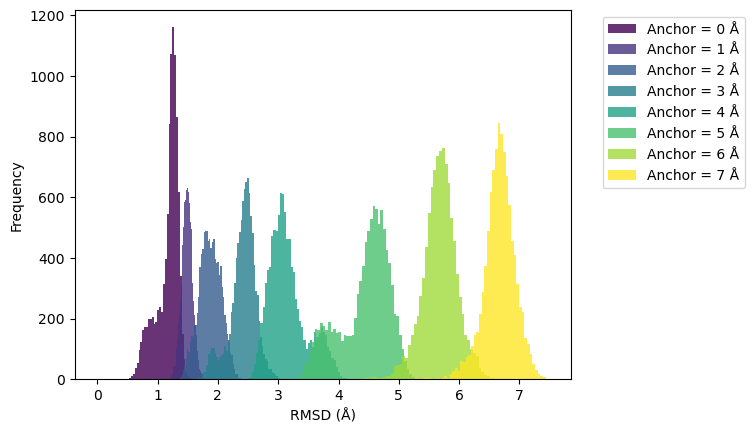

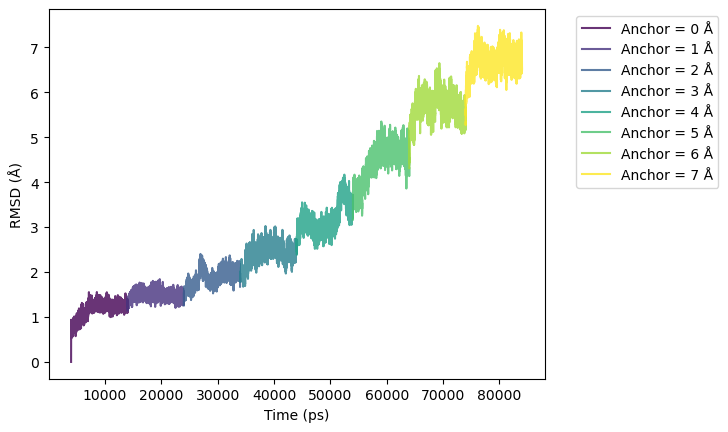

In [62]:
colv_VIPR_Rint_df_list = [colv0_VIPR_Rint_df, colv1_VIPR_Rint_df, colv2_VIPR_Rint_df, colv3_VIPR_Rint_df, 
                          colv4_VIPR_Rint_df, colv5_VIPR_Rint_df, colv6_VIPR_Rint_df, colv7_VIPR_Rint_df, ]
                          # colv8_VIPR_Rint_df, colv9_VIPR_Rint_df]

colors = cmap(np.linspace(0, 1, len(colv_VIPR_Rint_df_list)))

for df, label, color in zip(colv_VIPR_Rint_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(colv_VIPR_Rint_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Receptor + ligand

,MD time (ps),Collective variable (1:1)
0,4000.0,0.000497
1,4001.0,0.573801
2,4002.0,0.566403
3,4003.0,0.611352
4,4004.0,0.628114
...,...,...
9995,13995.0,1.332267
9996,13996.0,1.295074
9997,13997.0,1.289221
9998,13998.0,1.336356


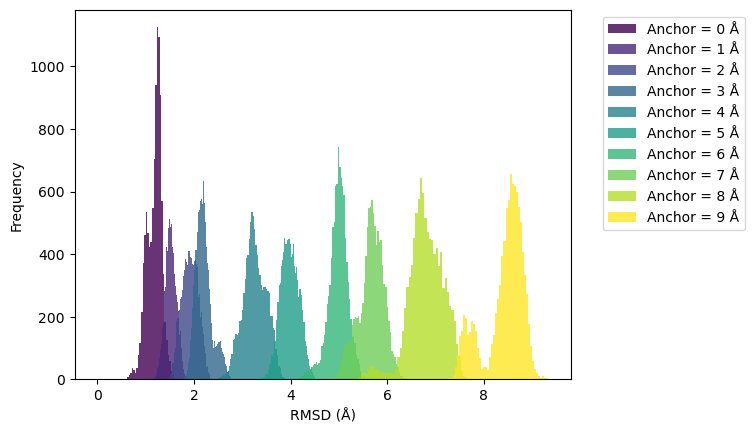

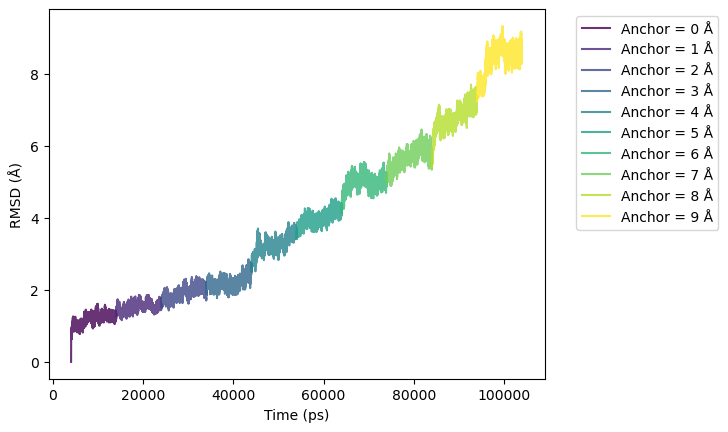

In [48]:
colv0_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv0.dat'
colv1_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv1.dat'
colv2_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv2.dat'
colv3_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv3.dat'
colv4_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv4.dat'
colv5_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv5.dat'
colv6_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv6.dat'
colv7_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv7.dat'
colv8_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv8.dat'
colv9_VIPR_RLint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor_ligand/finished/colv9.dat'

colv0_VIPR_RLint_df = pd.read_csv(colv0_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_VIPR_RLint_df)

colv1_VIPR_RLint_df = pd.read_csv(colv1_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_VIPR_RLint_df = pd.read_csv(colv2_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_VIPR_RLint_df = pd.read_csv(colv3_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_VIPR_RLint_df = pd.read_csv(colv4_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_VIPR_RLint_df = pd.read_csv(colv5_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_VIPR_RLint_df = pd.read_csv(colv6_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_VIPR_RLint_df = pd.read_csv(colv7_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_VIPR_RLint_df = pd.read_csv(colv8_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_VIPR_RLint_df = pd.read_csv(colv9_VIPR_RLint_path, comment='#', delim_whitespace=True, header=None, names=column_names)

colv_VIPR_RLint_df_list = [colv0_VIPR_RLint_df, colv1_VIPR_RLint_df, colv2_VIPR_RLint_df, colv3_VIPR_RLint_df, colv4_VIPR_RLint_df, colv5_VIPR_RLint_df, colv6_VIPR_RLint_df, colv7_VIPR_RLint_df, colv8_VIPR_RLint_df, colv9_VIPR_RLint_df]

colors = cmap(np.linspace(0, 1, len(colv_VIPR_RLint_df_list)))

for df, label, color in zip(colv_VIPR_RLint_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(colv_VIPR_RLint_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### VIPR$^{-}$

#### Receptor
1. running in cluster
2. ~~running locally (in case cluster does NOT start/end before results are required)~~ CANCELLED $\because$ \
    a. cluster is faster by 20 ns/day\
    b. keep AMBER20 constant

In [60]:
colv0_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv0.dat'
colv1_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv1.dat'
colv2_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv2.dat'
colv3_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv3.dat'
colv4_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv4.dat'
colv5_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv5.dat'
colv6_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv6.dat'
colv7_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv7.dat'
colv8_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv8.dat'
# colv9_noVIPR_Rint_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/colv9.dat'

colv0_noVIPR_Rint_df = pd.read_csv(colv0_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv1_noVIPR_Rint_df = pd.read_csv(colv1_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_noVIPR_Rint_df = pd.read_csv(colv2_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_noVIPR_Rint_df = pd.read_csv(colv3_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_noVIPR_Rint_df = pd.read_csv(colv4_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_noVIPR_Rint_df = pd.read_csv(colv5_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_noVIPR_Rint_df = pd.read_csv(colv6_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_noVIPR_Rint_df = pd.read_csv(colv7_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_noVIPR_Rint_df = pd.read_csv(colv8_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv8_noVIPR_Rint_df)
# colv9_noVIPR_Rint_df = pd.read_csv(colv9_noVIPR_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,83999.9999,6.834523
1,84000.9999,6.882086
2,84001.9999,6.995225
3,84002.9999,6.901237
4,84003.9999,6.963580
...,...,...
7401,91400.9999,8.124661
7402,91401.9999,7.827776
7403,91402.9999,8.047454
7404,91403.9999,8.060148


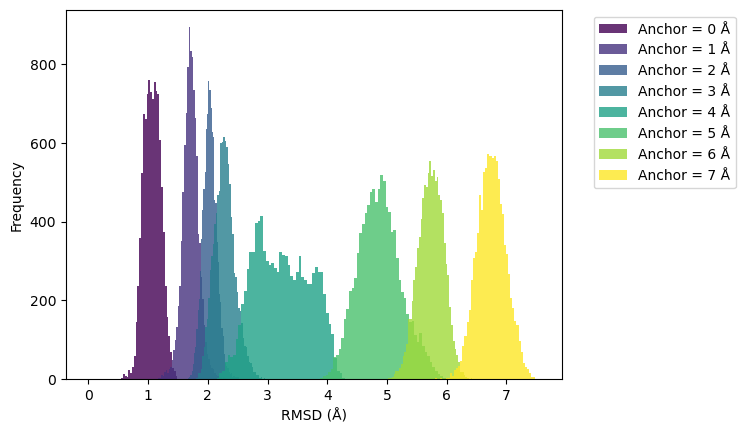

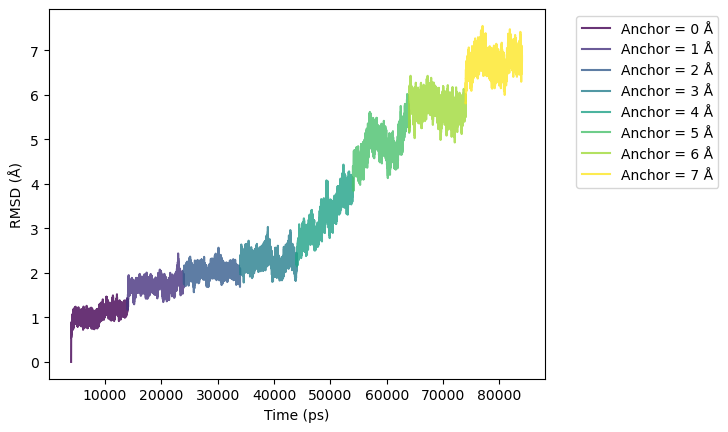

In [61]:
colv_noVIPR_Rint_df_list = [colv0_noVIPR_Rint_df, colv1_noVIPR_Rint_df, colv2_noVIPR_Rint_df, 
                          colv3_noVIPR_Rint_df, colv4_noVIPR_Rint_df, colv5_noVIPR_Rint_df, 
                          colv6_noVIPR_Rint_df, colv7_noVIPR_Rint_df, ]
                            # colv8_noVIPR_Rint_df, ]
                          # colv9_noVIPR_Rint_df]

colors = cmap(np.linspace(0, 1, len(colv_noVIPR_Rint_df_list)))

for df, label, color in zip(colv_noVIPR_Rint_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(colv_noVIPR_Rint_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Free energy

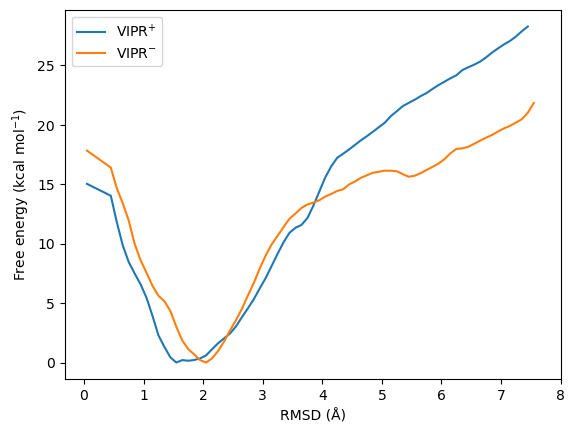

In [70]:
Rint_LS_VIPR_free_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/umbrella_sampling/receptor/finished/result_bootstrap.dat'
Rint_L_noVIPR_free_path = '/home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/umbrella_sampling/result_bootstrap.dat'

Rint_LS_VIPR_free_df = (pd.read_csv(Rint_LS_VIPR_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
Rint_L_noVIPR_free_df = (pd.read_csv(Rint_L_noVIPR_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))

sns.lineplot(x='Coor', y='Free', data=Rint_LS_VIPR_free_df, label='VIPR$^{+}$')
sns.lineplot(x='Coor', y='Free', data=Rint_L_noVIPR_free_df, label='VIPR$^{-}$')

plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.xticks(np.arange(0, 9, step=1))
plt.show()

In [68]:
from scipy.integrate import quad
from scipy.interpolate import interp1d
import math

In [64]:
def compute_delta_G_error(df, boltzmann_factor_kcal_molar, harmonic_constant_kcal, reference_rmsd, gas_constant_kcal, temperature):
    # Drop rows with NaN values in 'Free' column
    df_dropna = df.dropna(subset=['Free'])

    # Create an interpolation function for G_RMSD
    G_RMSD = interp1d(df_dropna['Coor'], df_dropna['Free'])

    # Define the integrand for the numerator
    def integrand_numerator(RMSD):
        return np.exp(-boltzmann_factor_kcal_molar * G_RMSD(RMSD)) * np.exp(
            -0.5 * boltzmann_factor_kcal_molar * harmonic_constant_kcal * (RMSD - reference_rmsd)**2)

    # Define the integrand for the denominator
    def integrand_denominator(RMSD):
        return np.exp(-boltzmann_factor_kcal_molar * G_RMSD(RMSD))

    # Compute the integrals
    integral_numerator, error_numerator = quad(integrand_numerator, df_dropna['Coor'].min(), df_dropna['Coor'].max())
    integral_denominator, error_denominator = quad(integrand_denominator, df_dropna['Coor'].min(), df_dropna['Coor'].max())

    # Compute delta G
    delta_G = - gas_constant_kcal * temperature * math.log( integral_numerator / integral_denominator )

    # Compute the error in delta G
    delta_G_error = gas_constant_kcal * temperature * math.sqrt((error_numerator / integral_numerator)**2 + (error_denominator / integral_denominator)**2)

    return delta_G, delta_G_error

In [65]:
k_B = 1.380658e-23 # J/K
T = 310 # K
beta = 1 / ( k_B * T ) # /J
print(f"Boltzmann factor in joule: {beta} /J")

Jtokcal = 4184 # J/kcal
beta_kcal = beta * Jtokcal  # /kcal
print(f"Boltzmann factor after conversion to kcal: {beta_kcal} /kcal")

N_A = 6.0221367e+23 # /mol
beta_kcal_molar = beta_kcal / N_A # mol/kcal
print(f"Boltzmann factor after conversion to moles: {beta_kcal_molar} mol/kcal")

R = 8.3145112 # J/K/mol
R_kcal = R / Jtokcal # kcal/K/mol
print(f"Gas constant after conversion to kcal: {R_kcal} kcal/K/mol")

k = 10 # kcal/mol/Å^2
RMSD_ref = 0 # Å (i.e., crystal structure)

Boltzmann factor in joule: 2.336426871544512e+20 /J
Boltzmann factor after conversion to kcal: 9.775610030542238e+23 /kcal
Boltzmann factor after conversion to moles: 1.6232793304978013 mol/kcal
Gas constant after conversion to kcal: 0.0019872158699808795 kcal/K/mol


In [71]:
delta_G_VIPR, error_delta_G_VIPR = compute_delta_G_error(Rint_LS_VIPR_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"With VIPR: {delta_G_VIPR} +/- {error_delta_G_VIPR} kcal/mol")

delta_G_noVIPR, error_delta_G_noVIPR = compute_delta_G_error(Rint_L_noVIPR_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Without VIPR: {delta_G_noVIPR} +/- {error_delta_G_noVIPR} kcal/mol")

With VIPR: 10.381466471060657 +/- 0.3432571328550672 kcal/mol
Without VIPR: 12.863296479190945 +/- 0.954990874151512 kcal/mol


/home/wjoon21/anaconda3/envs/ppis/lib/python3.7/site-packages/ipykernel_launcher.py:19: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


## NO ligand protein

### VIPR$^{+}$

#### Prepare topology

In [54]:
!pdb4amber -i /home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/noLigand/1of2_hla_noLigand_VIPR.pdb -o /home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/noLigand/1of2_hla_noLigand_VIPR_pdb4amber.pdb


Summary of pdb4amber for: /home/wjoon21/project/a02int/hla-b2709_vipr_1of2/VIPR/noLigand/1of2_hla_noLigand_VIPR.pdb

----------Chains
The following (original) chains have been found:
A
C

---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
GLN_72
GLU_166
ARG_169
ASP_196
-----------Non-standard-resnames


---------- Missing heavy atom(s)

HIS_3 misses 4 heavy atom(s)
ARG_6 misses 2 heavy atom(s)
TYR_7 misses 4 heavy atom(s)
PHE_8 misses 4 heavy atom(s)
HIS_9 misses 4 heavy atom(s)
THR_10 misses 2 heavy atom(s)
VAL_12 misses 2 heavy atom(s)
ARG_14 misses 2 heavy atom(s)
ARG_17 misses 2 heavy atom(s)
GLU_19 misses 2 heavy atom(s)
ARG_21 misses 2 heavy atom(s)
PHE_22 misses 4 heavy atom(s)
ILE_23 misses 3 heavy atom(s)
THR_24 misses 2 heavy atom(s)
VAL_25 misses 2 heavy atom(s)
TYR_27 misses 4 heavy atom(s)
VAL_28 misses 2 heavy atom(s)
ASP_29 misses 2 heavy atom(s)
ASP_30 misses 2 heavy atom(s)
THR_31 misses 2 heavy atom(s)
LEU_32 misses 

```tleap
Warning: The unperturbed charge of the unit (-7.000000) is not zero.
```
$\rightarrow$ added 7 Na$^{+}$

In [55]:
volumeBoxAngstrom = 756497.257
volumeBoxLiter = volumeBoxAngstrom * 1/(10**10)**3 * (10**2)**3/1 * 1/1 * 1/10**3
numberClLiter = 150/1 * 1/10**3 * (6.022*10**23)/1
numberClBox = volumeBoxLiter * numberClLiter
numberClBox

68.33439722480999

$\rightarrow$ added 68 Na$^{+}$ & 68 Cl$^{-}$

#### Minimization, heating, equilibration, 50 ns NVT MD
Changed `prod_unrestrained_md.in` from NPT to NVT (same as umbrella sampling `mdr_.in`) while equilibration was running

#### Umbrella sampling

### VIPR$^{-}$

#### Prepare topology

In [56]:
!pdb4amber -i /home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/noLigand/1of2_hla_noLigand_noVIPR.pdb -o /home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/noLigand/1of2_hla_noLigand_noVIPR_pdb4amber.pdb


Summary of pdb4amber for: /home/wjoon21/project/a02int/hla-b2709_vipr_1of2/noVIPR/noLigand/1of2_hla_noLigand_noVIPR.pdb

----------Chains
The following (original) chains have been found:
A

---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
GLN_72
GLU_166
ARG_169
ASP_196
-----------Non-standard-resnames


---------- Missing heavy atom(s)

HIS_3 misses 4 heavy atom(s)
ARG_6 misses 2 heavy atom(s)
TYR_7 misses 4 heavy atom(s)
PHE_8 misses 4 heavy atom(s)
HIS_9 misses 4 heavy atom(s)
THR_10 misses 2 heavy atom(s)
VAL_12 misses 2 heavy atom(s)
ARG_14 misses 2 heavy atom(s)
ARG_17 misses 2 heavy atom(s)
GLU_19 misses 2 heavy atom(s)
ARG_21 misses 2 heavy atom(s)
PHE_22 misses 4 heavy atom(s)
ILE_23 misses 3 heavy atom(s)
THR_24 misses 2 heavy atom(s)
VAL_25 misses 2 heavy atom(s)
TYR_27 misses 4 heavy atom(s)
VAL_28 misses 2 heavy atom(s)
ASP_29 misses 2 heavy atom(s)
ASP_30 misses 2 heavy atom(s)
THR_31 misses 2 heavy atom(s)
LEU_32 misse

```tleap
Warning: The unperturbed charge of the unit (-12.000000) is not zero.
```
$\rightarrow$ added 12 Na$^{+}$

In [57]:
volumeBoxAngstrom = 761878.343
volumeBoxLiter = volumeBoxAngstrom * 1/(10**10)**3 * (10**2)**3/1 * 1/1 * 1/10**3
numberClLiter = 150/1 * 1/10**3 * (6.022*10**23)/1
numberClBox = volumeBoxLiter * numberClLiter
numberClBox

68.82047072319

$\rightarrow$ added 69 Na$^{+}$ & 69 Cl$^{-}$

#### Minimization, heating, equilibration, 50 ns NVT MD
Changed `prod_unrestrained_md.in` from NPT to NVT (same as umbrella sampling `mdr_.in`) while equilibration was running

#### Umbrella sampling

## HREMD + US

### VIPR$^{+}$

### VIPR$^{-}$